# CS166: Restroom Queue Simulation

A cellular automata simulation analyzing the **restroom wait gap** between genders.

**Research Questions:**
1. What stall ratio minimizes the wait gap?
2. Is gender-neutral better than segregated?


In [76]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Optional, Tuple
from enum import IntEnum
from collections import deque
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')


In [77]:
class CellType(IntEnum):
    EMPTY = 0
    WALL = 1
    W_STALL = 2
    M_STALL = 3
    URINAL = 4
    SINK = 5
    QUEUE_W = 6
    QUEUE_M = 7
    QUEUE_SHARED = 8
    ENTRANCE = 9
    EXIT = 10

class PersonState(IntEnum):
    WALKING_TO_QUEUE = 0
    IN_QUEUE = 1
    WALKING_TO_STALL = 2
    IN_STALL = 3
    WALKING_TO_SINK = 4
    AT_SINK = 5
    EXITING = 6
    DONE = 7

CELL_COLORS = {
    CellType.EMPTY: '#f5f5f5',
    CellType.WALL: '#333333',
    CellType.W_STALL: '#ffc1e3',
    CellType.M_STALL: '#b3d9ff',
    CellType.URINAL: '#4a90e2',
    CellType.SINK: '#ce93d8',
    CellType.QUEUE_W: '#ffccf2',
    CellType.QUEUE_M: '#d6eaff',
    CellType.QUEUE_SHARED: '#e1f5fe',
    CellType.ENTRANCE: '#c8e6c9',
    CellType.EXIT: '#ffccbc',
}


## Core Data Structures


In [78]:
@dataclass
class Stall:
    col: int
    row: int
    stall_type: str
    gender_allowed: str
    entrance_col: int
    entrance_row: int
    occupant_id: Optional[int] = None
    busy_time: float = 0.0  # Track total busy time for utilization

@dataclass
class Sink:
    col: int
    row: int
    entrance_col: int
    entrance_row: int
    occupant_id: Optional[int] = None
    busy_time: float = 0.0

@dataclass
class QueueCell:
    col: int
    row: int
    gender: str

@dataclass
class Person:
    """Agent with proper timestamp tracking."""
    id: int
    col: int
    row: int
    gender: str
    dwell_time: float
    sink_time: float
    will_use_sink: bool  # NEW: probabilistic sink usage
    
    # Timestamps (all in simulation seconds)
    time_entered: float = 0.0
    time_joined_queue: Optional[float] = None
    time_started_stall: Optional[float] = None
    time_left_stall: Optional[float] = None
    time_started_sink: Optional[float] = None
    time_left_sink: Optional[float] = None
    time_exited: Optional[float] = None
    
    state: PersonState = PersonState.WALKING_TO_QUEUE
    target_queue_idx: Optional[int] = None
    target_stall: Optional[Stall] = None
    target_sink: Optional[Sink] = None
    
    @property
    def queue_wait(self) -> Optional[float]:
        """Time spent waiting in queue for stall."""
        if self.time_joined_queue and self.time_started_stall:
            return self.time_started_stall - self.time_joined_queue
        return None
    
    @property
    def total_time(self) -> Optional[float]:
        """Total time in system."""
        if self.time_exited:
            return self.time_exited - self.time_entered
        return None


In [79]:
class Grid:
    def __init__(self, cols: int, rows: int):
        self.cols = cols
        self.rows = rows
        self.cells = np.zeros((rows, cols), dtype=int)
        self.stalls: List[Stall] = []
        self.sinks: List[Sink] = []
        self.queue_cells_women: List[QueueCell] = []
        self.queue_cells_men: List[QueueCell] = []
        self.queue_cells_shared: List[QueueCell] = []
        self.entrance_cell = None
        self.exit_cell = None
        self.entrance_women = None
        self.entrance_men = None
    
    def set_cell(self, row, col, cell_type):
        if 0 <= row < self.rows and 0 <= col < self.cols:
            self.cells[row, col] = cell_type
    
    def get_cell(self, row, col):
        if 0 <= row < self.rows and 0 <= col < self.cols:
            return CellType(self.cells[row, col])
        return CellType.WALL
    
    def draw_border(self):
        self.cells[0, :] = CellType.WALL
        self.cells[-1, :] = CellType.WALL
        self.cells[:, 0] = CellType.WALL
        self.cells[:, -1] = CellType.WALL
    
    def add_stall(self, col, row, gender, stall_type='stall'):
        if stall_type == 'urinal':
            cell_type = CellType.URINAL
            gender_allowed = 'M'
        elif gender == 'F':
            cell_type = CellType.W_STALL
            gender_allowed = 'F'
        else:
            cell_type = CellType.M_STALL
            gender_allowed = 'M'
        
        self.set_cell(row, col, cell_type)
        self.stalls.append(Stall(
            col=col, row=row, stall_type=stall_type,
            gender_allowed=gender_allowed,
            entrance_col=col, entrance_row=row + 1
        ))
    
    def add_sink(self, col, row):
        self.set_cell(row, col, CellType.SINK)
        self.sinks.append(Sink(col=col, row=row, entrance_col=col, entrance_row=row + 1))
    
    def add_queue_cell(self, col, row, gender):
        if gender == 'F':
            self.set_cell(row, col, CellType.QUEUE_W)
            self.queue_cells_women.append(QueueCell(col, row, gender))
        elif gender == 'M':
            self.set_cell(row, col, CellType.QUEUE_M)
            self.queue_cells_men.append(QueueCell(col, row, gender))
        else:
            self.set_cell(row, col, CellType.QUEUE_SHARED)
            self.queue_cells_shared.append(QueueCell(col, row, 'shared'))
    
    def set_entrance(self, col, row, gender=None):
        self.set_cell(row, col, CellType.ENTRANCE)
        if gender == 'F':
            self.entrance_women = (col, row)
        elif gender == 'M':
            self.entrance_men = (col, row)
        else:
            self.entrance_cell = (col, row)
    
    def set_exit(self, col, row):
        self.set_cell(row, col, CellType.EXIT)
        self.exit_cell = (col, row)


In [80]:
def find_next_step(start_col, start_row, goal_col, goal_row, is_walkable, cols, rows):
    """BFS pathfinding - returns next cell to move to."""
    if start_col == goal_col and start_row == goal_row:
        return None
    
    queue = deque([(start_col, start_row)])
    visited = {(start_col, start_row)}
    parent = {}
    
    while queue:
        col, row = queue.popleft()
        
        if col == goal_col and row == goal_row:
            # Backtrack
            path = []
            curr = (col, row)
            while curr in parent:
                path.append(curr)
                curr = parent[curr]
            return path[-1] if path else None
        
        for dc, dr in [(0, -1), (1, 0), (0, 1), (-1, 0)]:
            nc, nr = col + dc, row + dr
            if 0 <= nc < cols and 0 <= nr < rows and (nc, nr) not in visited:
                if is_walkable(nc, nr):
                    visited.add((nc, nr))
                    parent[(nc, nr)] = (col, row)
                    queue.append((nc, nr))
    return None


In [81]:
class CASimulation:
    def __init__(self, grid: Grid, 
                 arrival_rate: float = 2.0,
                 dwell_time_female: Tuple[float, float] = (70, 110),
                 dwell_time_male_stall: Tuple[float, float] = (50, 80),
                 dwell_time_male_urinal: Tuple[float, float] = (30, 50),
                 sink_time_range: Tuple[float, float] = (10, 20),
                 p_wash_female: float = 0.95,
                 p_wash_male: float = 0.67,
                 p_male_urinal: float = 0.85,
                 seconds_per_tick: float = 1.0,
                 seed: int = 42):
        
        self.grid = grid
        self.arrival_rate = arrival_rate
        self.dwell_time_female = dwell_time_female
        self.dwell_time_male_stall = dwell_time_male_stall
        self.dwell_time_male_urinal = dwell_time_male_urinal
        self.sink_time_range = sink_time_range
        self.p_wash_female = p_wash_female
        self.p_wash_male = p_wash_male
        self.p_male_urinal = p_male_urinal
        self.seconds_per_tick = seconds_per_tick
        
        self.rng = np.random.default_rng(seed)
        self.people: List[Person] = []
        self.completed: List[Person] = []  # Track finished people separately
        self.next_id = 1
        self.sim_time = 0.0
    
    def reset(self):
        self.people = []
        self.completed = []
        self.next_id = 1
        self.sim_time = 0.0
        for s in self.grid.stalls:
            s.occupant_id = None
            s.busy_time = 0.0
        for s in self.grid.sinks:
            s.occupant_id = None
            s.busy_time = 0.0
    
    def step(self):
        self.sim_time += self.seconds_per_tick
        
        # Arrivals (Poisson)
        lambda_per_sec = self.arrival_rate / 60
        n_arrivals = self.rng.poisson(lambda_per_sec * self.seconds_per_tick)
        for _ in range(n_arrivals):
            self._spawn_person()
        
        # Update utilization tracking
        for s in self.grid.stalls:
            if s.occupant_id is not None:
                s.busy_time += self.seconds_per_tick
        for s in self.grid.sinks:
            if s.occupant_id is not None:
                s.busy_time += self.seconds_per_tick
        
        # Update agents
        for p in self.people[:]:
            if p.state != PersonState.DONE:
                self._update_person(p)
        
        self._maintain_queues()
    
    def _spawn_person(self):
        gender = 'F' if self.rng.random() < 0.5 else 'M'
        
        # Find entrance
        if gender == 'F' and self.grid.entrance_women:
            entrance = self.grid.entrance_women
        elif gender == 'M' and self.grid.entrance_men:
            entrance = self.grid.entrance_men
        elif self.grid.entrance_cell:
            entrance = self.grid.entrance_cell
        else:
            return
        
        # Gender-specific dwell times
        if gender == 'F':
            dwell = self.rng.uniform(*self.dwell_time_female)
            will_wash = self.rng.random() < self.p_wash_female
        else:
            # Will be adjusted if using urinal
            dwell = self.rng.uniform(*self.dwell_time_male_stall)
            will_wash = self.rng.random() < self.p_wash_male
        
        sink_time = self.rng.uniform(*self.sink_time_range) if will_wash else 0
        
        p = Person(
            id=self.next_id,
            col=entrance[0], row=entrance[1],
            gender=gender,
            dwell_time=dwell,
            sink_time=sink_time,
            will_use_sink=will_wash,
            time_entered=self.sim_time
        )
        self.next_id += 1
        self.people.append(p)
    
    def _update_person(self, p: Person):
        if p.state == PersonState.WALKING_TO_QUEUE:
            self._walk_to_queue(p)
        elif p.state == PersonState.IN_QUEUE:
            self._in_queue(p)
        elif p.state == PersonState.WALKING_TO_STALL:
            self._walk_to_stall(p)
        elif p.state == PersonState.IN_STALL:
            self._in_stall(p)
        elif p.state == PersonState.WALKING_TO_SINK:
            self._walk_to_sink(p)
        elif p.state == PersonState.AT_SINK:
            self._at_sink(p)
        elif p.state == PersonState.EXITING:
            self._exiting(p)
    
    def _get_queue_cells(self, gender):
        if self.grid.queue_cells_shared:
            return self.grid.queue_cells_shared
        return self.grid.queue_cells_women if gender == 'F' else self.grid.queue_cells_men
    
    def _walk_to_queue(self, p: Person):
        if p.target_queue_idx is None:
            queue = self._get_queue_cells(p.gender)
            occupied = {pp.target_queue_idx for pp in self.people 
                       if pp.gender == p.gender and pp.state != PersonState.DONE 
                       and pp.target_queue_idx is not None}
            for i in range(len(queue) - 1, -1, -1):
                if i not in occupied:
                    p.target_queue_idx = i
                    break
            if p.target_queue_idx is None:
                p.target_queue_idx = len(queue) - 1
        
        queue = self._get_queue_cells(p.gender)
        if p.target_queue_idx >= len(queue):
            p.state = PersonState.EXITING
            return
        
        target = queue[p.target_queue_idx]
        self._step_toward(p, target.col, target.row)
        
        if p.col == target.col and p.row == target.row:
            p.state = PersonState.IN_QUEUE
            p.time_joined_queue = self.sim_time
    
    def _in_queue(self, p: Person):
        queue = self._get_queue_cells(p.gender)
        if p.target_queue_idx is not None and p.target_queue_idx < len(queue):
            target = queue[p.target_queue_idx]
            p.col, p.row = target.col, target.row
        
        if p.target_queue_idx == 0:
            stall = self._find_available_stall(p.gender)
            if stall:
                stall.occupant_id = p.id
                p.target_stall = stall
                p.state = PersonState.WALKING_TO_STALL
                p.target_queue_idx = None
                self._shift_queue(p.gender)
    
    def _find_available_stall(self, gender):
        available = [s for s in self.grid.stalls if s.occupant_id is None]
        
        if not self.grid.queue_cells_shared:
            available = [s for s in available if s.gender_allowed == gender or s.gender_allowed == 'both']
        
        if gender == 'M' and self.rng.random() < self.p_male_urinal:
            urinals = [s for s in available if s.stall_type == 'urinal']
            if urinals:
                return urinals[0]
        
        non_urinals = [s for s in available if s.stall_type != 'urinal']
        return non_urinals[0] if non_urinals else (available[0] if available else None)
    
    def _shift_queue(self, gender):
        for pp in self.people:
            if (pp.gender == gender and pp.state == PersonState.IN_QUEUE and 
                pp.target_queue_idx is not None and pp.target_queue_idx > 0):
                pp.target_queue_idx -= 1
    
    def _walk_to_stall(self, p: Person):
        if not p.target_stall:
            p.state = PersonState.WALKING_TO_SINK if p.will_use_sink else PersonState.EXITING
            return
        
        self._step_toward(p, p.target_stall.entrance_col, p.target_stall.entrance_row)
        
        if p.col == p.target_stall.entrance_col and p.row == p.target_stall.entrance_row:
            p.col, p.row = p.target_stall.col, p.target_stall.row
            p.state = PersonState.IN_STALL
            p.time_started_stall = self.sim_time
            
            # Adjust dwell time for urinal
            if p.target_stall.stall_type == 'urinal' and p.gender == 'M':
                p.dwell_time = self.rng.uniform(*self.dwell_time_male_urinal)
    
    def _in_stall(self, p: Person):
        if p.time_started_stall and self.sim_time - p.time_started_stall >= p.dwell_time:
            p.time_left_stall = self.sim_time
            if p.target_stall:
                p.target_stall.occupant_id = None
                p.target_stall = None
            p.state = PersonState.WALKING_TO_SINK if p.will_use_sink else PersonState.EXITING
    
    def _walk_to_sink(self, p: Person):
        if not p.target_sink:
            available = [s for s in self.grid.sinks if s.occupant_id is None]
            if available:
                p.target_sink = available[0]
                p.target_sink.occupant_id = p.id
            else:
                # Wait for sink (don't skip)
                return
        
        self._step_toward(p, p.target_sink.entrance_col, p.target_sink.entrance_row)
        
        if p.col == p.target_sink.entrance_col and p.row == p.target_sink.entrance_row:
            p.col, p.row = p.target_sink.col, p.target_sink.row
            p.state = PersonState.AT_SINK
            p.time_started_sink = self.sim_time
    
    def _at_sink(self, p: Person):
        if p.time_started_sink and self.sim_time - p.time_started_sink >= p.sink_time:
            p.time_left_sink = self.sim_time
            if p.target_sink:
                p.target_sink.occupant_id = None
                p.target_sink = None
            p.state = PersonState.EXITING
    
    def _exiting(self, p: Person):
        if not self.grid.exit_cell:
            self._finish_person(p)
            return
        
        self._step_toward(p, self.grid.exit_cell[0], self.grid.exit_cell[1])
        
        if p.col == self.grid.exit_cell[0] and p.row == self.grid.exit_cell[1]:
            self._finish_person(p)
    
    def _finish_person(self, p: Person):
        p.state = PersonState.DONE
        p.time_exited = self.sim_time
        self.completed.append(p)
        self.people.remove(p)
    
    def _step_toward(self, p: Person, target_col, target_row):
        def is_walkable(col, row):
            if col < 0 or col >= self.grid.cols or row < 0 or row >= self.grid.rows:
                return False
            cell = self.grid.get_cell(row, col)
            if cell == CellType.WALL:
                return False
            if cell in [CellType.W_STALL, CellType.M_STALL, CellType.URINAL, CellType.SINK]:
                return p.col == col and p.row == row
            for other in self.people:
                if other != p and other.col == col and other.row == row:
                    return False
            return True
        
        next_step = find_next_step(p.col, p.row, target_col, target_row,
                                   is_walkable, self.grid.cols, self.grid.rows)
        if next_step:
            p.col, p.row = next_step
    
    def _maintain_queues(self):
        for gender in ['F', 'M']:
            queue = self._get_queue_cells(gender)
            if not queue:
                continue
            
            occupied = {}
            for pp in self.people:
                if pp.gender == gender and pp.state == PersonState.IN_QUEUE:
                    if pp.target_queue_idx is not None:
                        occupied[pp.target_queue_idx] = pp
            
            for i in range(len(queue)):
                if i not in occupied:
                    for j in range(i + 1, len(queue)):
                        if j in occupied:
                            occupied[j].target_queue_idx = i
                            break
    
    def get_stall_utilization(self):
        if not self.grid.stalls or self.sim_time == 0:
            return 0.0
        total_busy = sum(s.busy_time for s in self.grid.stalls)
        return total_busy / (len(self.grid.stalls) * self.sim_time)
    
    def get_sink_utilization(self):
        if not self.grid.sinks or self.sim_time == 0:
            return 0.0
        total_busy = sum(s.busy_time for s in self.grid.sinks)
        return total_busy / (len(self.grid.sinks) * self.sim_time)


## Layout Builders


In [82]:
def build_segregated_layout(n_stalls_female=5, n_stalls_male=3, n_urinals=2, n_sinks=2):
    cols = 24
    rows = 14
    grid = Grid(cols, rows)
    grid.draw_border()
    
    mid_col = cols // 2
    
    # Divider
    for r in range(1, rows - 1):
        grid.set_cell(r, mid_col, CellType.WALL)
    
    # Women's side
    for i in range(n_stalls_female):
        grid.add_stall(col=2 + i * 2, row=2, gender='F')
    
    # Sinks: ensure at least 1 per side if n_sinks >= 2
    n_sinks_w = max(1, n_sinks // 2) if n_sinks > 0 else 0
    n_sinks_m = n_sinks - n_sinks_w
    for i in range(n_sinks_w):
        grid.add_sink(col=3 + i * 2, row=5)
    
    for c in range(2, mid_col):
        grid.add_queue_cell(col=c, row=9, gender='F')
    grid.set_entrance(col=5, row=rows - 2, gender='F')
    
    # Men's side
    for i in range(n_stalls_male):
        grid.add_stall(col=mid_col + 2 + i * 2, row=2, gender='M')
    for i in range(n_urinals):
        grid.add_stall(col=mid_col + 2 + n_stalls_male * 2 + i, row=2, gender='M', stall_type='urinal')
    for i in range(n_sinks_m):
        grid.add_sink(col=mid_col + 3 + i * 2, row=5)
    for c in range(mid_col + 1, cols - 2):
        grid.add_queue_cell(col=c, row=9, gender='M')
    grid.set_entrance(col=mid_col + 5, row=rows - 2, gender='M')
    
    grid.set_exit(col=mid_col, row=rows - 2)
    return grid


def build_gender_neutral_layout(n_stalls=10, n_sinks=3):
    cols = 24
    rows = 14
    grid = Grid(cols, rows)
    grid.draw_border()
    
    # Shared stalls
    for i in range(min(n_stalls, 10)):
        grid.add_stall(col=2 + i * 2, row=2, gender='F')
        grid.stalls[-1].gender_allowed = 'both'
    
    # Sinks (at least 1)
    n_sinks = max(1, n_sinks)
    for i in range(n_sinks):
        grid.add_sink(col=3 + i * 3, row=5)
    
    # Shared queue
    for c in range(3, cols - 3):
        grid.add_queue_cell(col=c, row=9, gender='shared')
    
    grid.set_entrance(col=cols // 2, row=rows - 2)
    grid.set_exit(col=cols - 3, row=rows - 2)
    return grid


print("Layout builders ready.")
g = build_segregated_layout()
print(f"Segregated: {len(g.stalls)} stalls, {len(g.sinks)} sinks")
g2 = build_gender_neutral_layout(10, 1)
print(f"Gender-neutral (1 sink): {len(g2.stalls)} stalls, {len(g2.sinks)} sinks")


Layout builders ready.
Segregated: 10 stalls, 2 sinks
Gender-neutral (1 sink): 10 stalls, 1 sinks


## Visualization

Draw the simulation state with agents moving on the grid.


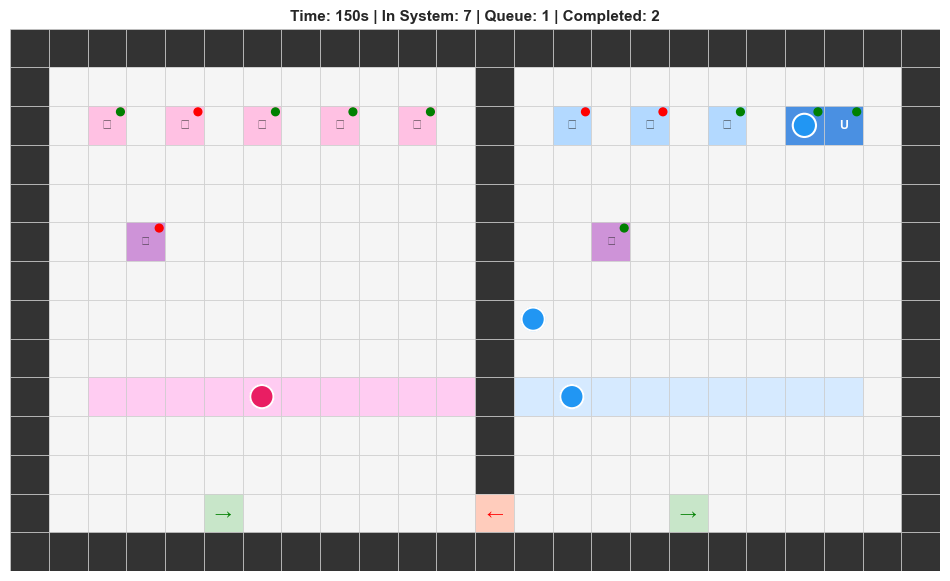

In [83]:
def draw_simulation(sim, ax=None):
    """Draw the current simulation state."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
    else:
        ax.clear()
    
    grid = sim.grid
    
    # Draw cells
    for row in range(grid.rows):
        for col in range(grid.cols):
            cell_type = grid.get_cell(row, col)
            color = CELL_COLORS.get(cell_type, '#ffffff')
            rect = plt.Rectangle((col, grid.rows - 1 - row), 1, 1,
                                  facecolor=color, edgecolor='#cccccc', linewidth=0.5)
            ax.add_patch(rect)
            
            # Fixture symbols
            cx, cy = col + 0.5, grid.rows - 1 - row + 0.5
            if cell_type == CellType.W_STALL:
                ax.text(cx, cy, '🚺', ha='center', va='center', fontsize=10)
            elif cell_type == CellType.M_STALL:
                ax.text(cx, cy, '🚹', ha='center', va='center', fontsize=10)
            elif cell_type == CellType.URINAL:
                ax.text(cx, cy, 'U', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
            elif cell_type == CellType.SINK:
                ax.text(cx, cy, '🚰', ha='center', va='center', fontsize=9)
            elif cell_type == CellType.ENTRANCE:
                ax.text(cx, cy, '→', ha='center', va='center', fontsize=12, color='green', fontweight='bold')
            elif cell_type == CellType.EXIT:
                ax.text(cx, cy, '←', ha='center', va='center', fontsize=12, color='red', fontweight='bold')
    
    # Occupancy indicators
    for stall in grid.stalls:
        cx, cy = stall.col + 0.85, grid.rows - 1 - stall.row + 0.85
        color = 'red' if stall.occupant_id else 'green'
        ax.add_patch(plt.Circle((cx, cy), 0.1, color=color, zorder=10))
    
    for sink in grid.sinks:
        cx, cy = sink.col + 0.85, grid.rows - 1 - sink.row + 0.85
        color = 'red' if sink.occupant_id else 'green'
        ax.add_patch(plt.Circle((cx, cy), 0.1, color=color, zorder=10))
    
    # Draw people
    for p in sim.people:
        if p.state in [PersonState.IN_STALL, PersonState.AT_SINK]:
            continue  # Inside fixture
        
        cx = p.col + 0.5
        cy = grid.rows - 1 - p.row + 0.5
        color = '#e91e63' if p.gender == 'F' else '#2196f3'
        ax.add_patch(plt.Circle((cx, cy), 0.3, color=color, zorder=20))
        ax.add_patch(plt.Circle((cx, cy), 0.3, fill=False, color='white', linewidth=1.5, zorder=21))
    
    ax.set_xlim(0, grid.cols)
    ax.set_ylim(0, grid.rows)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Stats
    in_queue = len([p for p in sim.people if p.state == PersonState.IN_QUEUE])
    ax.set_title(f"Time: {sim.sim_time:.0f}s | In System: {len(sim.people)} | Queue: {in_queue} | Completed: {len(sim.completed)}",
                fontsize=11, fontweight='bold')
    return ax

# Show a snapshot
grid = build_segregated_layout(5, 3, 2)
sim = CASimulation(grid, arrival_rate=4.0, seed=42)
for _ in range(150):
    sim.step()

fig, ax = plt.subplots(figsize=(12, 8))
draw_simulation(sim, ax)
plt.savefig('fig_snapshot.png', dpi=150, bbox_inches='tight')
plt.show()


### Animation

Watch the simulation in real-time.


In [84]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def create_animation(grid_fn, n_frames=150, interval=80):
    """Create animated simulation."""
    grid = grid_fn()
    sim = CASimulation(grid, arrival_rate=4.0, seed=42)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    def update(frame):
        for _ in range(2):  # 2 steps per frame
            sim.step()
        draw_simulation(sim, ax)
        return []
    
    anim = FuncAnimation(fig, update, frames=n_frames, interval=interval, blit=False)
    plt.close(fig)
    return anim

# Create and display animation
print("Creating animation... (this may take a moment)")
anim = create_animation(lambda: build_segregated_layout(5, 3, 2), n_frames=100)
HTML(anim.to_jshtml())


Creating animation... (this may take a moment)


---
## Verification Tests

In [85]:
def run_tests():
    """Run verification tests with expected outcomes."""
    results = []
    
    # Test 1: No arrivals => no people served
    print("Test 1: No arrivals (arrival_rate=0)")
    grid = build_segregated_layout()
    sim = CASimulation(grid, arrival_rate=0)
    for _ in range(100):
        sim.step()
    passed = len(sim.completed) == 0 and len(sim.people) == 0
    print(f"  Expected: 0 served, 0 in system")
    print(f"  Got: {len(sim.completed)} served, {len(sim.people)} in system")
    print(f"  {'✓ PASS' if passed else '✗ FAIL'}")
    results.append(passed)
    
    # Test 2: Single person deterministic
    print("\nTest 2: Single person, deterministic times")
    grid = build_segregated_layout()
    sim = CASimulation(grid, arrival_rate=0, seed=99)
    p = Person(id=1, col=5, row=12, gender='F', dwell_time=60, sink_time=10, will_use_sink=True, time_entered=0)
    sim.people.append(p)
    for _ in range(300):
        sim.step()
    if sim.completed:
        total = sim.completed[0].total_time
        passed = total is not None and total >= 70
        print(f"  Expected: total_time >= 70s")
        print(f"  Got: {total:.1f}s")
    else:
        passed = False
        print(f"  Person not completed (still in state {p.state})")
    print(f"  {'✓ PASS' if passed else '✗ FAIL'}")
    results.append(passed)
    
    # Test 3: Bottleneck - use gender-neutral with many stalls, few sinks
    print("\nTest 3: Sink bottleneck (10 stalls, 1 sink, gender-neutral)")
    grid = build_gender_neutral_layout(n_stalls=10, n_sinks=1)
    sim = CASimulation(grid, arrival_rate=5.0, seed=42, p_wash_female=1.0, p_wash_male=1.0,
                       sink_time_range=(20, 40))
    for _ in range(400):
        sim.step()
    sink_util = sim.get_sink_utilization()
    stall_util = sim.get_stall_utilization()
    passed = sink_util > stall_util and sink_util > 0.5
    print(f"  Expected: sink_util > stall_util (sink is bottleneck)")
    print(f"  Got: sink={sink_util:.1%}, stall={stall_util:.1%}")
    print(f"  {'✓ PASS' if passed else '✗ FAIL'}")
    results.append(passed)
    
    # Test 4: More stalls should reduce queue wait
    print("\nTest 4: More stalls => lower queue wait")
    waits = []
    for n_stalls in [3, 6]:
        grid = build_segregated_layout(n_stalls_female=n_stalls, n_stalls_male=n_stalls, n_urinals=2)
        sim = CASimulation(grid, arrival_rate=4.0, seed=42)
        for _ in range(500):
            sim.step()
        qw = [p.queue_wait for p in sim.completed if p.queue_wait is not None]
        waits.append(np.mean(qw) if qw else 0)
    passed = waits[1] <= waits[0]
    print(f"  Expected: wait(6 stalls) <= wait(3 stalls)")
    print(f"  Got: 3 stalls={waits[0]:.1f}s, 6 stalls={waits[1]:.1f}s")
    print(f"  {'✓ PASS' if passed else '✗ FAIL'}")
    results.append(passed)
    
    # Test 5: Reproducibility (same seed => same results)
    print("\nTest 5: Reproducibility (same seed)")
    outputs = []
    for _ in range(2):
        grid = build_segregated_layout()
        sim = CASimulation(grid, arrival_rate=5.0, seed=123)
        for _ in range(400):
            sim.step()
        outputs.append((len(sim.completed), round(sim.get_stall_utilization(), 4)))
    passed = outputs[0] == outputs[1] and outputs[0][0] > 0
    print(f"  Expected: identical outputs with >0 completed")
    print(f"  Got: run1={outputs[0]}, run2={outputs[1]}")
    print(f"  {'✓ PASS' if passed else '✗ FAIL'}")
    results.append(passed)
    
    # Test 6: Steady state - queue doesn't explode
    print("\nTest 6: Steady state (queue bounded)")
    grid = build_segregated_layout(n_stalls_female=4, n_stalls_male=3, n_urinals=2)  # Slightly constrained
    sim = CASimulation(grid, arrival_rate=4.0, seed=42)  # Moderate load
    queue_lens = []
    for step in range(800):
        sim.step()
        if step >= 200:  # After warmup
            q_len = len([p for p in sim.people if p.state == PersonState.IN_QUEUE])
            queue_lens.append(q_len)
    
    mean_queue = np.mean(queue_lens)
    max_queue = np.max(queue_lens)
    # System is stable if: mean queue is bounded, doesn't grow unboundedly
    passed = mean_queue < 15 and max_queue < 30
    print(f"  Expected: mean_queue < 15, max_queue < 30 (stable system)")
    print(f"  Got: mean={mean_queue:.1f}, max={max_queue}")
    print(f"  {'✓ PASS' if passed else '✗ FAIL'}")
    results.append(passed)
    
    print("\n" + "="*50)
    print(f"RESULTS: {sum(results)}/{len(results)} tests passed")
    print("="*50)
    return all(results)

run_tests()


Test 1: No arrivals (arrival_rate=0)
  Expected: 0 served, 0 in system
  Got: 0 served, 0 in system
  ✓ PASS

Test 2: Single person, deterministic times
  Expected: total_time >= 70s
  Got: 115.0s
  ✓ PASS

Test 3: Sink bottleneck (10 stalls, 1 sink, gender-neutral)
  Expected: sink_util > stall_util (sink is bottleneck)
  Got: sink=76.2%, stall=56.2%
  ✓ PASS

Test 4: More stalls => lower queue wait
  Expected: wait(6 stalls) <= wait(3 stalls)
  Got: 3 stalls=18.6s, 6 stalls=16.8s
  ✓ PASS

Test 5: Reproducibility (same seed)
  Expected: identical outputs with >0 completed
  Got: run1=(19, 0.5258), run2=(19, 0.5258)
  ✓ PASS

Test 6: Steady state (queue bounded)
  Expected: mean_queue < 15, max_queue < 30 (stable system)
  Got: mean=0.9, max=4
  ✓ PASS

RESULTS: 6/6 tests passed


True

---
## Experiments

In [86]:
def run_monte_carlo(grid_fn, n_runs=20, n_steps=500, warmup=100, **sim_kwargs):
    """
    Run Monte Carlo simulation with proper metric collection.
    
    Returns dict with arrays of per-run metrics.
    """
    results = {
        'queue_waits_female': [],
        'queue_waits_male': [],
        'total_times_female': [],
        'total_times_male': [],
        'stall_utils': [],
        'sink_utils': [],
        'all_queue_waits': [],  # For distribution plots
    }
    
    for run in range(n_runs):
        grid = grid_fn()
        sim = CASimulation(grid, seed=42 + run, **sim_kwargs)
        
        for _ in range(n_steps):
            sim.step()
        
        # Collect queue waits from completed people
        f_waits = [p.queue_wait for p in sim.completed if p.gender == 'F' and p.queue_wait is not None]
        m_waits = [p.queue_wait for p in sim.completed if p.gender == 'M' and p.queue_wait is not None]
        
        results['queue_waits_female'].append(np.mean(f_waits) if f_waits else 0)
        results['queue_waits_male'].append(np.mean(m_waits) if m_waits else 0)
        results['all_queue_waits'].extend(f_waits + m_waits)
        
        f_total = [p.total_time for p in sim.completed if p.gender == 'F' and p.total_time is not None]
        m_total = [p.total_time for p in sim.completed if p.gender == 'M' and p.total_time is not None]
        results['total_times_female'].append(np.mean(f_total) if f_total else 0)
        results['total_times_male'].append(np.mean(m_total) if m_total else 0)
        
        results['stall_utils'].append(sim.get_stall_utilization())
        results['sink_utils'].append(sim.get_sink_utilization())
    
    return results


def ci95(data):
    """Compute mean and 95% CI half-width."""
    if len(data) < 2:
        return np.mean(data) if data else 0, 0
    mean = np.mean(data)
    h = stats.sem(data) * stats.t.ppf(0.975, len(data) - 1)
    return mean, h


print("Monte Carlo framework ready.")


Monte Carlo framework ready.


### Experiment 1: Optimal Stall Ratio

Vary women:men stall ratio while keeping total fixed.


Running Experiment 1: Stall Ratio Analysis
  3:5 - Women: 19.2s, Men: 15.9s, Gap: +3.4s
  4:4 - Women: 16.6s, Men: 20.3s, Gap: -3.8s
  5:3 - Women: 16.7s, Men: 19.9s, Gap: -3.2s
  6:2 - Women: 16.6s, Men: 18.5s, Gap: -1.9s
  7:1 - Women: 16.6s, Men: 17.9s, Gap: -1.3s


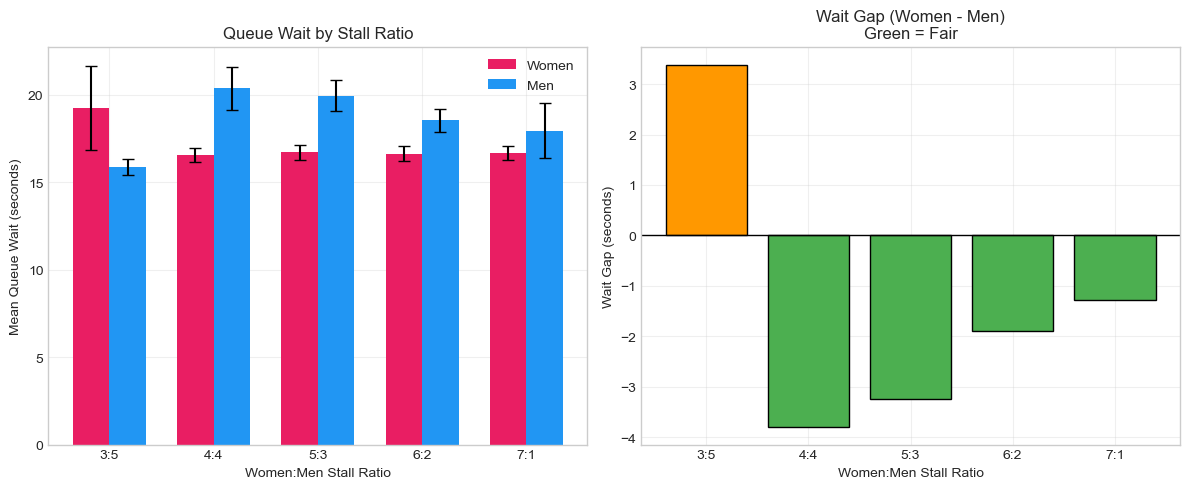

In [87]:
# Experiment 1: Stall Ratio
print("Running Experiment 1: Stall Ratio Analysis")
print("="*50)

ratios = [(3, 5), (4, 4), (5, 3), (6, 2), (7, 1)]
exp1 = []

for n_f, n_m in ratios:
    grid_fn = lambda nf=n_f, nm=n_m: build_segregated_layout(n_stalls_female=nf, n_stalls_male=nm, n_urinals=2)
    res = run_monte_carlo(grid_fn, n_runs=15)
    
    f_mean, f_ci = ci95(res['queue_waits_female'])
    m_mean, m_ci = ci95(res['queue_waits_male'])
    gap = f_mean - m_mean
    
    exp1.append({'ratio': f'{n_f}:{n_m}', 'f_wait': f_mean, 'f_ci': f_ci, 
                 'm_wait': m_mean, 'm_ci': m_ci, 'gap': gap})
    print(f"  {n_f}:{n_m} - Women: {f_mean:.1f}s, Men: {m_mean:.1f}s, Gap: {gap:+.1f}s")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(exp1))
labels = [e['ratio'] for e in exp1]

# Wait times by gender
ax1 = axes[0]
w = 0.35
ax1.bar(x - w/2, [e['f_wait'] for e in exp1], w, yerr=[e['f_ci'] for e in exp1], 
        label='Women', color='#e91e63', capsize=4)
ax1.bar(x + w/2, [e['m_wait'] for e in exp1], w, yerr=[e['m_ci'] for e in exp1], 
        label='Men', color='#2196f3', capsize=4)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_xlabel('Women:Men Stall Ratio')
ax1.set_ylabel('Mean Queue Wait (seconds)')
ax1.set_title('Queue Wait by Stall Ratio')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wait gap
ax2 = axes[1]
gaps = [e['gap'] for e in exp1]
colors = ['#f44336' if g > 5 else '#ff9800' if g > 0 else '#4caf50' for g in gaps]
ax2.bar(x, gaps, color=colors, edgecolor='black')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_xlabel('Women:Men Stall Ratio')
ax2.set_ylabel('Wait Gap (seconds)')
ax2.set_title('Wait Gap (Women - Men)\nGreen = Fair')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_stall_ratio.png', dpi=150, bbox_inches='tight')
plt.show()


### Experiment 2: Urinal Count


Running Experiment 2: Urinal Count
  0 urinals - Women: 16.7s, Men: 18.2s, Gap: -1.5s
  2 urinals - Women: 16.7s, Men: 19.9s, Gap: -3.2s
  4 urinals - Women: 16.6s, Men: 20.4s, Gap: -3.8s
  6 urinals - Women: 16.6s, Men: 20.4s, Gap: -3.8s


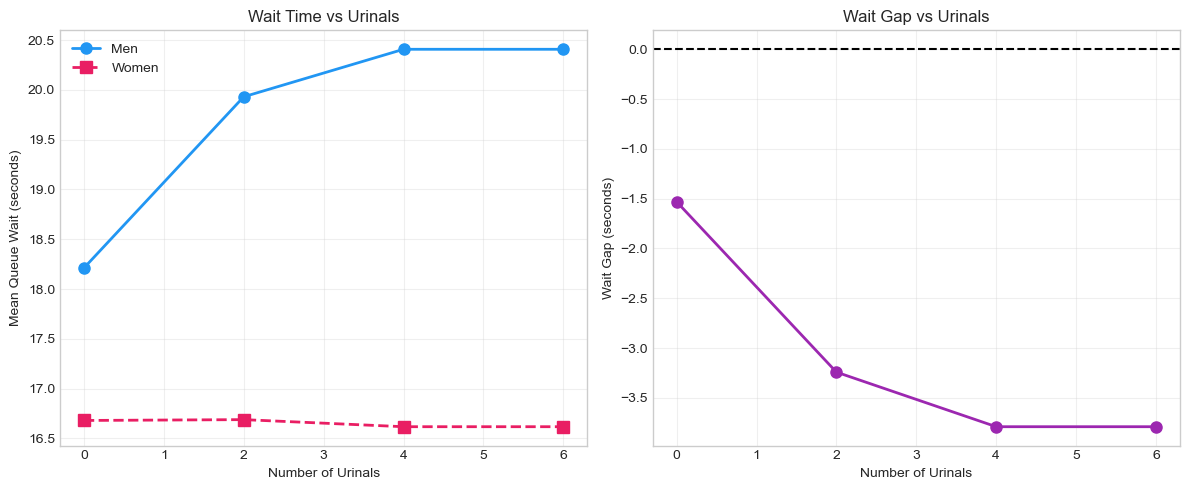

In [88]:
# Experiment 2: Urinals
print("Running Experiment 2: Urinal Count")
print("="*50)

urinal_counts = [0, 2, 4, 6]
exp2 = []

for n_u in urinal_counts:
    grid_fn = lambda nu=n_u: build_segregated_layout(n_stalls_female=5, n_stalls_male=3, n_urinals=nu)
    res = run_monte_carlo(grid_fn, n_runs=15)
    
    f_mean, _ = ci95(res['queue_waits_female'])
    m_mean, m_ci = ci95(res['queue_waits_male'])
    gap = f_mean - m_mean
    
    exp2.append({'urinals': n_u, 'f_wait': f_mean, 'm_wait': m_mean, 'm_ci': m_ci, 'gap': gap})
    print(f"  {n_u} urinals - Women: {f_mean:.1f}s, Men: {m_mean:.1f}s, Gap: {gap:+.1f}s")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

urinals = [e['urinals'] for e in exp2]

ax1.plot(urinals, [e['m_wait'] for e in exp2], 'o-', linewidth=2, markersize=8, color='#2196f3', label='Men')
ax1.plot(urinals, [e['f_wait'] for e in exp2], 's--', linewidth=2, markersize=8, color='#e91e63', label='Women')
ax1.set_xlabel('Number of Urinals')
ax1.set_ylabel('Mean Queue Wait (seconds)')
ax1.set_title('Wait Time vs Urinals')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(urinals, [e['gap'] for e in exp2], 'o-', linewidth=2, markersize=8, color='#9c27b0')
ax2.axhline(0, color='black', linestyle='--')
ax2.set_xlabel('Number of Urinals')
ax2.set_ylabel('Wait Gap (seconds)')
ax2.set_title('Wait Gap vs Urinals')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_urinals.png', dpi=150, bbox_inches='tight')
plt.show()


### Throughput Analysis


Measuring throughput across layouts...
  5:3 (gap+): 21 completed, gap=+0.5s
  6:2 (balanced): 21 completed, gap=-0.6s
  7:1 (gap-): 21 completed, gap=-2.7s
  GN-10: 22 completed, gap=+0.3s


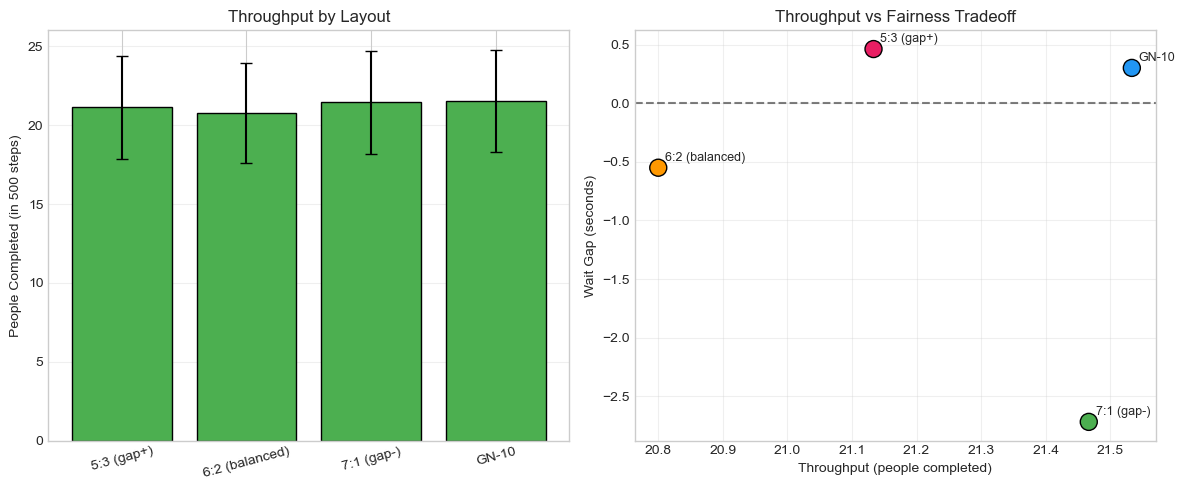

In [89]:
# Throughput comparison
print("Measuring throughput across layouts...")

throughput_layouts = [
    ('5:3 (gap+)', lambda: build_segregated_layout(5, 3, 2)),
    ('6:2 (balanced)', lambda: build_segregated_layout(6, 2, 2)),
    ('7:1 (gap-)', lambda: build_segregated_layout(7, 1, 2)),
    ('GN-10', lambda: build_gender_neutral_layout(10, 2)),
]

throughput_results = []
for name, grid_fn in throughput_layouts:
    completions = []
    gaps = []
    for run in range(15):
        grid = grid_fn()
        sim = CASimulation(grid, seed=42+run, arrival_rate=4.0)
        for _ in range(500):
            sim.step()
        completions.append(len(sim.completed))
        f_wait = np.mean([p.queue_wait for p in sim.completed if p.gender=='F' and p.queue_wait]) or 0
        m_wait = np.mean([p.queue_wait for p in sim.completed if p.gender=='M' and p.queue_wait]) or 0
        gaps.append(f_wait - m_wait)
    
    throughput_results.append({
        'name': name,
        'throughput': np.mean(completions),
        'throughput_std': np.std(completions),
        'gap': np.mean(gaps),
        'gap_std': np.std(gaps)
    })
    print(f"  {name}: {np.mean(completions):.0f} completed, gap={np.mean(gaps):+.1f}s")

# Plot: Throughput vs Gap tradeoff
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

names = [r['name'] for r in throughput_results]
x = np.arange(len(names))

# Throughput bars
ax1.bar(x, [r['throughput'] for r in throughput_results], 
        yerr=[r['throughput_std'] for r in throughput_results],
        color='#4caf50', capsize=4, edgecolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=15)
ax1.set_ylabel('People Completed (in 500 steps)')
ax1.set_title('Throughput by Layout')
ax1.grid(True, alpha=0.3, axis='y')

# Scatter: Throughput vs Gap
ax2.scatter([r['throughput'] for r in throughput_results],
            [r['gap'] for r in throughput_results],
            s=150, c=['#e91e63', '#ff9800', '#4caf50', '#2196f3'], edgecolor='black')
for i, r in enumerate(throughput_results):
    ax2.annotate(r['name'], (r['throughput'], r['gap']), 
                 xytext=(5, 5), textcoords='offset points', fontsize=9)
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Throughput (people completed)')
ax2.set_ylabel('Wait Gap (seconds)')
ax2.set_title('Throughput vs Fairness Tradeoff')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_throughput.png', dpi=150, bbox_inches='tight')
plt.show()


### Queue Length Over Time

Recording queue dynamics...


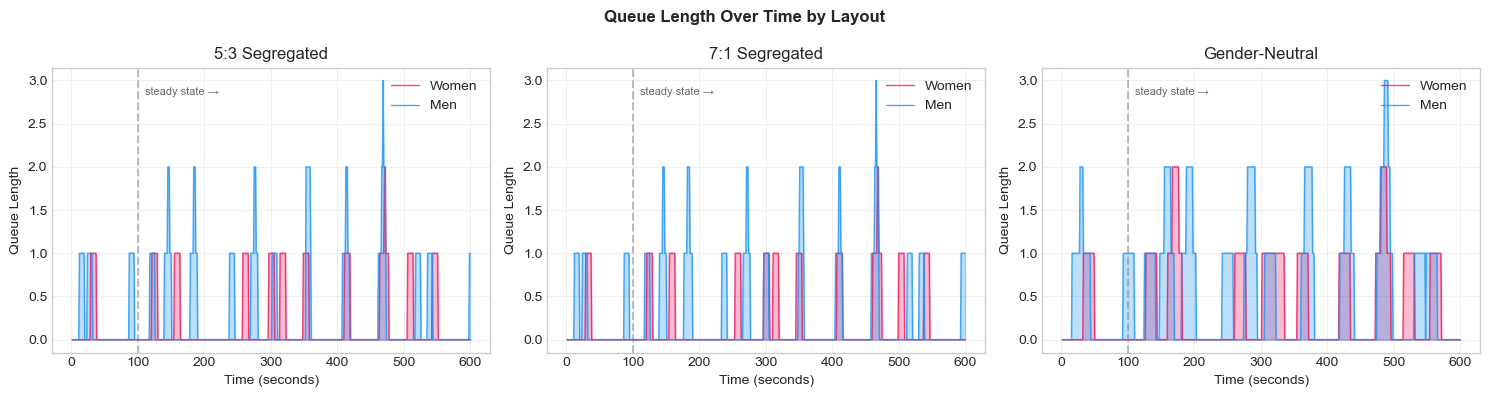

In [90]:
# Time series of queue length
print("Recording queue dynamics...")

time_series_layouts = [
    ('5:3 Segregated', lambda: build_segregated_layout(5, 3, 2), '#e91e63'),
    ('7:1 Segregated', lambda: build_segregated_layout(7, 1, 2), '#4caf50'),
    ('Gender-Neutral', lambda: build_gender_neutral_layout(10, 2), '#2196f3'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, grid_fn, color) in enumerate(time_series_layouts):
    grid = grid_fn()
    sim = CASimulation(grid, seed=42, arrival_rate=4.0)
    
    times = []
    queue_f = []
    queue_m = []
    
    for step in range(600):
        sim.step()
        times.append(sim.sim_time)
        queue_f.append(len([p for p in sim.people if p.gender=='F' and p.state == PersonState.IN_QUEUE]))
        queue_m.append(len([p for p in sim.people if p.gender=='M' and p.state == PersonState.IN_QUEUE]))
    
    ax = axes[idx]
    ax.plot(times, queue_f, label='Women', color='#e91e63', alpha=0.8, linewidth=1)
    ax.plot(times, queue_m, label='Men', color='#2196f3', alpha=0.8, linewidth=1)
    ax.fill_between(times, queue_f, alpha=0.3, color='#e91e63')
    ax.fill_between(times, queue_m, alpha=0.3, color='#2196f3')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Queue Length')
    ax.set_title(name)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Mark steady state region
    ax.axvline(100, color='gray', linestyle='--', alpha=0.5)
    ax.text(110, ax.get_ylim()[1]*0.9, 'steady state →', fontsize=8, alpha=0.7)

plt.suptitle('Queue Length Over Time by Layout', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_queue_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


### Histogram of Outcomes

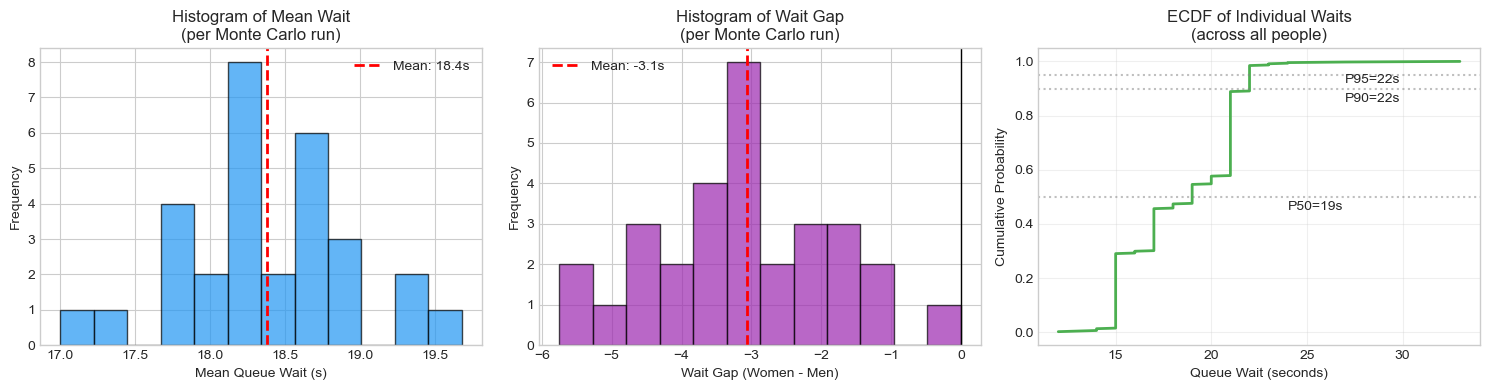

In [91]:
# Run longer simulation for histograms
print("Collecting distributions for histograms...")
grid_fn = lambda: build_segregated_layout(n_stalls_female=5, n_stalls_male=3, n_urinals=2)
hist_res = run_monte_carlo(grid_fn, n_runs=30, n_steps=600)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of mean wait per run
ax1 = axes[0]
all_means = [(f + m) / 2 for f, m in zip(hist_res['queue_waits_female'], hist_res['queue_waits_male'])]
ax1.hist(all_means, bins=12, color='#2196f3', edgecolor='black', alpha=0.7)
ax1.axvline(np.mean(all_means), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_means):.1f}s')
ax1.set_xlabel('Mean Queue Wait (s)')
ax1.set_ylabel('Frequency')
ax1.set_title('Histogram of Mean Wait\n(per Monte Carlo run)')
ax1.legend()

# Histogram of wait gap
ax2 = axes[1]
gaps = [f - m for f, m in zip(hist_res['queue_waits_female'], hist_res['queue_waits_male'])]
ax2.hist(gaps, bins=12, color='#9c27b0', edgecolor='black', alpha=0.7)
ax2.axvline(0, color='black', linewidth=1)
ax2.axvline(np.mean(gaps), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(gaps):+.1f}s')
ax2.set_xlabel('Wait Gap (Women - Men)')
ax2.set_ylabel('Frequency')
ax2.set_title('Histogram of Wait Gap\n(per Monte Carlo run)')
ax2.legend()

# ECDF of individual waits
ax3 = axes[2]
all_waits = sorted(hist_res['all_queue_waits'])
if all_waits:
    y = np.arange(1, len(all_waits) + 1) / len(all_waits)
    ax3.plot(all_waits, y, linewidth=2, color='#4caf50')
    p50 = np.percentile(all_waits, 50)
    p90 = np.percentile(all_waits, 90)
    p95 = np.percentile(all_waits, 95)
    ax3.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax3.axhline(0.9, color='gray', linestyle=':', alpha=0.5)
    ax3.axhline(0.95, color='gray', linestyle=':', alpha=0.5)
    ax3.annotate(f'P50={p50:.0f}s', xy=(p50, 0.5), xytext=(p50+5, 0.45))
    ax3.annotate(f'P90={p90:.0f}s', xy=(p90, 0.9), xytext=(p90+5, 0.85))
    ax3.annotate(f'P95={p95:.0f}s', xy=(p95, 0.95), xytext=(p95+5, 0.92))
ax3.set_xlabel('Queue Wait (seconds)')
ax3.set_ylabel('Cumulative Probability')
ax3.set_title('ECDF of Individual Waits\n(across all people)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_histograms.png', dpi=150, bbox_inches='tight')
plt.show()


### Utilization Analysis


Analyzing utilization...
  5:3 Seg: stall=22.2%, sink=32.0%
  7:1 Seg: stall=21.7%, sink=30.8%
  GN-10: stall=23.6%, sink=20.6%


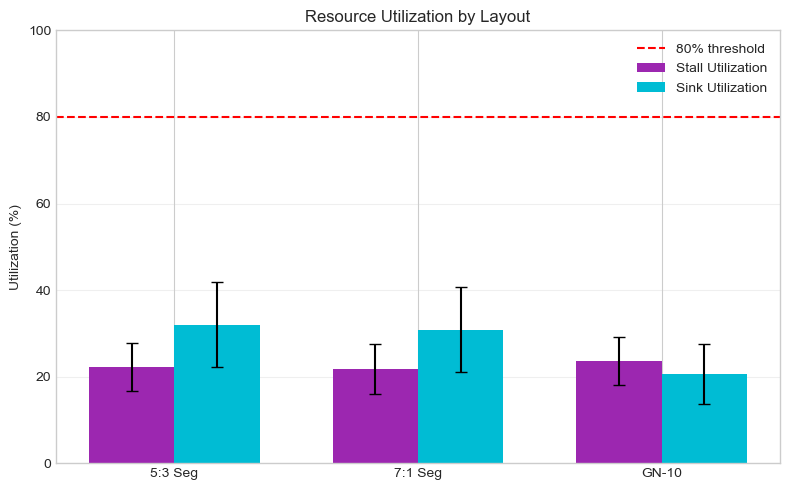

In [92]:
# Compare utilization across layouts
print("Analyzing utilization...")

layouts = [
    ('5:3 Seg', lambda: build_segregated_layout(5, 3, 2)),
    ('7:1 Seg', lambda: build_segregated_layout(7, 1, 2)),
    ('GN-10', lambda: build_gender_neutral_layout(10, 2)),
]

util_results = []
for name, grid_fn in layouts:
    res = run_monte_carlo(grid_fn, n_runs=15)
    util_results.append({
        'name': name,
        'stall': np.mean(res['stall_utils']) * 100,
        'sink': np.mean(res['sink_utils']) * 100,
        'stall_ci': np.std(res['stall_utils']) * 100,
        'sink_ci': np.std(res['sink_utils']) * 100,
    })
    print(f"  {name}: stall={util_results[-1]['stall']:.1f}%, sink={util_results[-1]['sink']:.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(util_results))
w = 0.35

ax.bar(x - w/2, [r['stall'] for r in util_results], w, 
       yerr=[r['stall_ci'] for r in util_results],
       label='Stall Utilization', color='#9c27b0', capsize=4)
ax.bar(x + w/2, [r['sink'] for r in util_results], w,
       yerr=[r['sink_ci'] for r in util_results],
       label='Sink Utilization', color='#00bcd4', capsize=4)

ax.axhline(80, color='red', linestyle='--', label='80% threshold')
ax.set_xticks(x)
ax.set_xticklabels([r['name'] for r in util_results])
ax.set_ylabel('Utilization (%)')
ax.set_title('Resource Utilization by Layout')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('fig4_utilization.png', dpi=150, bbox_inches='tight')
plt.show()


### Convergence Analysis

Running convergence analysis...


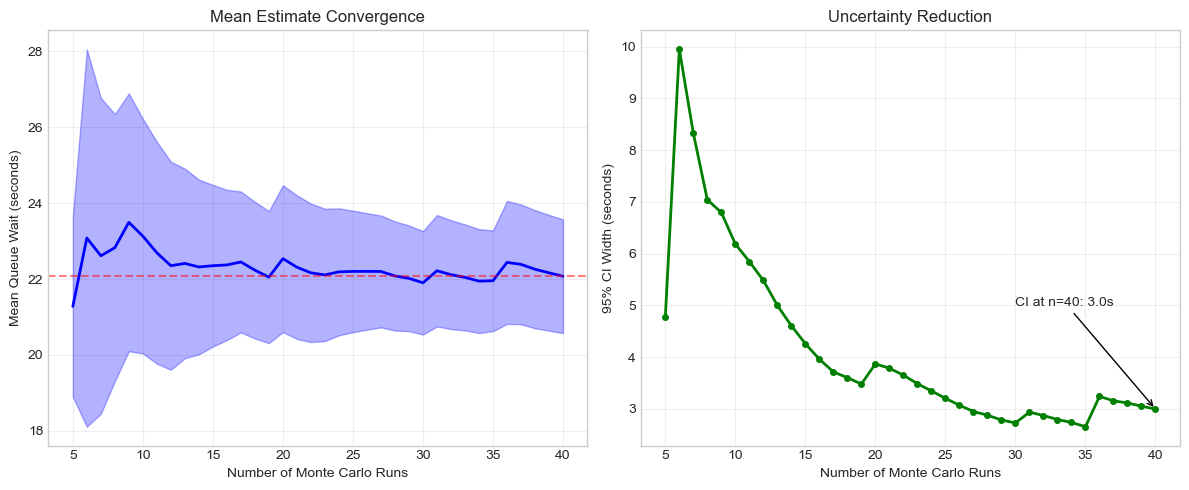


With 40 runs, 95% CI width = 3.0s


In [93]:
# Convergence: collect many runs and show CI shrinkage
print("Running convergence analysis...")

grid_fn = lambda: build_segregated_layout(5, 3, 2)

# Collect 40 runs worth of data
wait_means = []
for run in range(40):
    grid = grid_fn()
    sim = CASimulation(grid, seed=100 + run, arrival_rate=4.0)
    for _ in range(500):
        sim.step()
    waits = [p.queue_wait for p in sim.completed if p.queue_wait is not None]
    wait_means.append(np.mean(waits) if wits else 0)

# Calculate cumulative CI
n_runs = list(range(5, len(wait_means) + 1))
cumulative_means = []
ci_widths = []

for n in n_runs:
    subset = wait_means[:n]
    mean, h = ci95(subset)
    cumulative_means.append(mean)
    ci_widths.append(2 * h)  # Full CI width

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(n_runs, cumulative_means, 'b-', linewidth=2)
ax1.fill_between(n_runs, 
                 [m - w/2 for m, w in zip(cumulative_means, ci_widths)],
                 [m + w/2 for m, w in zip(cumulative_means, ci_widths)],
                 alpha=0.3, color='blue')
ax1.axhline(cumulative_means[-1], color='red', linestyle='--', alpha=0.5)
ax1.set_xlabel('Number of Monte Carlo Runs')
ax1.set_ylabel('Mean Queue Wait (seconds)')
ax1.set_title('Mean Estimate Convergence')
ax1.grid(True, alpha=0.3)

ax2.plot(n_runs, ci_widths, 'g-', linewidth=2, marker='o', markersize=4)
ax2.set_xlabel('Number of Monte Carlo Runs')
ax2.set_ylabel('95% CI Width (seconds)')
ax2.set_title('Uncertainty Reduction')
ax2.grid(True, alpha=0.3)

# Annotate
ax2.annotate(f'CI at n=40: {ci_widths[-1]:.1f}s', xy=(40, ci_widths[-1]),
             xytext=(30, ci_widths[-1] + 2), fontsize=10,
             arrowprops=dict(arrowstyle='->'))

plt.tight_layout()
plt.savefig('fig5_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nWith 40 runs, 95% CI width = {ci_widths[-1]:.1f}s")


### Sensitivity Analysis


Running sensitivity analysis...
  p_wash_male=0.3: Gap=-2.9s
  p_wash_male=0.5: Gap=-2.9s
  p_wash_male=0.67: Gap=-3.2s
  p_wash_male=0.9: Gap=-3.2s
  p_wash_male=1.0: Gap=-3.2s


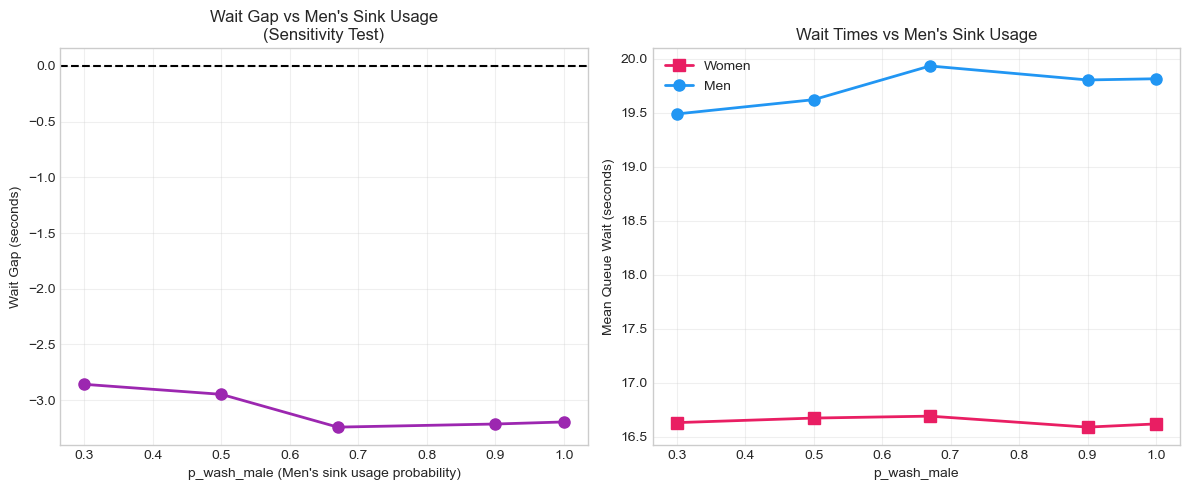

In [94]:
# Sensitivity: vary p_wash_male
print("Running sensitivity analysis...")

p_wash_values = [0.3, 0.5, 0.67, 0.9, 1.0]
sensitivity_results = []

for p_wash in p_wash_values:
    grid_fn = lambda: build_segregated_layout(5, 3, 2)
    res = run_monte_carlo(grid_fn, n_runs=15, p_wash_male=p_wash)
    
    f_mean = np.mean(res['queue_waits_female'])
    m_mean = np.mean(res['queue_waits_male'])
    gap = f_mean - m_mean
    
    sensitivity_results.append({'p_wash': p_wash, 'gap': gap, 'f_wait': f_mean, 'm_wait': m_mean})
    print(f"  p_wash_male={p_wash}: Gap={gap:+.1f}s")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x = [r['p_wash'] for r in sensitivity_results]

ax1.plot(x, [r['gap'] for r in sensitivity_results], 'o-', linewidth=2, markersize=8, color='#9c27b0')
ax1.axhline(0, color='black', linestyle='--')
ax1.set_xlabel('p_wash_male (Men\'s sink usage probability)')
ax1.set_ylabel('Wait Gap (seconds)')
ax1.set_title('Wait Gap vs Men\'s Sink Usage\n(Sensitivity Test)')
ax1.grid(True, alpha=0.3)

ax2.plot(x, [r['f_wait'] for r in sensitivity_results], 's-', linewidth=2, markersize=8, color='#e91e63', label='Women')
ax2.plot(x, [r['m_wait'] for r in sensitivity_results], 'o-', linewidth=2, markersize=8, color='#2196f3', label='Men')
ax2.set_xlabel('p_wash_male')
ax2.set_ylabel('Mean Queue Wait (seconds)')
ax2.set_title('Wait Times vs Men\'s Sink Usage')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Theoretical Validation

In [99]:
# Parameters for 5:3 segregated layout
lambda_total = 4.0 / 60  # arrivals per second
lambda_f = lambda_total * 0.5  # women arrivals
lambda_m = lambda_total * 0.5  # men arrivals

mu_f = 1 / 90  # women service rate (1/90s)
mu_m_stall = 1 / 65  # men stall rate
mu_m_urinal = 1 / 40  # men urinal rate

c_f = 5  # women stalls
c_m = 3 + 2  # men stalls + urinals

rho_f = lambda_f / (c_f * mu_f)
rho_m = lambda_m / (c_m * mu_m_stall)

print(f"\nArrival rate: λ = {lambda_total*60:.1f} people/min")
print(f"\nWomen's side:")
print(f"  λ_f = {lambda_f*60:.2f}/min, μ_f = {mu_f*60:.3f}/min, c = {c_f}")
print(f"  ρ_f = λ/(c*μ) = {rho_f:.2f}")
print(f"  → {'Stable' if rho_f < 1 else 'UNSTABLE (ρ ≥ 1)'}")

print(f"\nMen's side:")
print(f"  λ_m = {lambda_m*60:.2f}/min, c = {c_m}")
print(f"  ρ_m ≈ {rho_m:.2f}")
print(f"  → {'Stable' if rho_m < 1 else 'UNSTABLE (ρ ≥ 1)'}")

print(f"\nNote: Higher ρ means longer waits (W ∝ ρ/(1-ρ))")
print(f"Women's ρ ({rho_f:.2f}) > Men's ρ ({rho_m:.2f})")
print(f"→ Theory predicts women wait longer, matching simulation.")


Arrival rate: λ = 4.0 people/min

Women's side:
  λ_f = 2.00/min, μ_f = 0.667/min, c = 5
  ρ_f = λ/(c*μ) = 0.60
  → Stable

Men's side:
  λ_m = 2.00/min, c = 5
  ρ_m ≈ 0.43
  → Stable

Note: Higher ρ means longer waits (W ∝ ρ/(1-ρ))
Women's ρ (0.60) > Men's ρ (0.43)
→ Theory predicts women wait longer, matching simulation.
